In [1]:
from langgraph.graph import StateGraph, START, END
from typing import Literal, TypedDict, Annotated
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver

In [2]:
from langchain_huggingface import HuggingFaceEndpoint, ChatHuggingFace
import os

In [4]:
load_dotenv()

True

In [5]:
api_token = os.getenv("HUGGINGFACE_API_KEY")

llm = HuggingFaceEndpoint(
    repo_id="meta-llama/Llama-3.1-8B-Instruct",
    task="conversational",
    max_new_tokens=100,
    temperature=0.1,
    huggingfacehub_api_token=api_token,
)

chat_model = ChatHuggingFace(llm=llm)

In [14]:
class JokeState(TypedDict):
    topic: str
    joke: str
    explanation: str

In [21]:
def generate_joke(JokeState) -> JokeState:
    topic = JokeState['topic']
    joke = chat_model.invoke(f"Generate a joke about {topic}").content
    return {'joke': joke}

In [22]:
def explain_joke(JokeState):
    joke = JokeState['joke']
    explanation = chat_model.invoke(f"Explain the following joke: {joke}").content
    return {'explanation': explanation}

In [27]:
graph = StateGraph(JokeState)

#add nodes
graph.add_node('generate_joke',generate_joke)
graph.add_node('explain_joke',explain_joke)

#add edges
graph.add_edge(START,'generate_joke')
graph.add_edge('generate_joke','explain_joke')
graph.add_edge('explain_joke',END)

#checkpointer
checkpointer = InMemorySaver()

#compile graph
joke_gen = graph.compile(checkpointer=checkpointer)

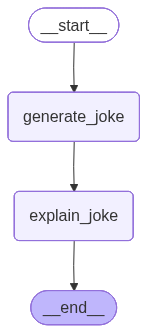

In [28]:
joke_gen

In [35]:
config1 = {'configurable': {'thread_id': '1'}}
initial_state = {'topic': 'pizzas'}
final_state = joke_gen.invoke(initial_state, config=config1)
print(final_state)

{'topic': 'pizzas', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words. The phrase "feeling a little crusty" has a double meaning here. \n\nIn everyday language, "feeling a little crusty" can mean being a bit grumpy or irritable. However, in the context of a pizza, "crusty" refers to the outer layer of the bread that is crispy and golden brown. \n\nThe joke relies on this wordplay to create a pun, connecting the pizza\'s physical characteristic (crusty) to'}


In [36]:
joke_gen.get_state(config1)

StateSnapshot(values={'topic': 'pizzas', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words. The phrase "feeling a little crusty" has a double meaning here. \n\nIn everyday language, "feeling a little crusty" can mean being a bit grumpy or irritable. However, in the context of a pizza, "crusty" refers to the outer layer of the bread that is crispy and golden brown. \n\nThe joke relies on this wordplay to create a pun, connecting the pizza\'s physical characteristic (crusty) to'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f167b50-17a8-6129-8006-fb5fded946aa'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-06-14T05:50:53.674237+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f167b50-08d5-6c1a-8005-6efbdbf8acf0'}}, tasks=(), interrupts=())

In [37]:
list(joke_gen.get_state_history(config1))

[StateSnapshot(values={'topic': 'pizzas', 'joke': 'Why was the pizza in a bad mood? \n\nBecause it was feeling a little crusty.', 'explanation': 'This joke is a play on words. The phrase "feeling a little crusty" has a double meaning here. \n\nIn everyday language, "feeling a little crusty" can mean being a bit grumpy or irritable. However, in the context of a pizza, "crusty" refers to the outer layer of the bread that is crispy and golden brown. \n\nThe joke relies on this wordplay to create a pun, connecting the pizza\'s physical characteristic (crusty) to'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f167b50-17a8-6129-8006-fb5fded946aa'}}, metadata={'source': 'loop', 'step': 6, 'parents': {}}, created_at='2026-06-14T05:50:53.674237+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f167b50-08d5-6c1a-8005-6efbdbf8acf0'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'pizzas', 

In [38]:
config2 = {
    'configurable': {
        'thread_id': '2'
    }
}
initial_state = {'topic': 'programming'}
final_state = joke_gen.invoke(initial_state, config=config1)
print(final_state)

{'topic': 'programming', 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.', 'explanation': 'This joke is a play on words. In programming, a "bug" refers to an error or a glitch in the code. However, in the physical world, a "bug" is also a small insect, often attracted to light.\n\nThe joke is saying that programmers prefer dark mode (a display setting that reduces the amount of light emitted by a screen) because light (in the physical sense) attracts bugs (in the programming sense). It\'s a clever pun that combines two different meanings of the'}


In [40]:
list(joke_gen.get_state_history(config2))

[StateSnapshot(values={'topic': 'programming', 'joke': 'Why do programmers prefer dark mode?\n\nBecause light attracts bugs.', 'explanation': 'This joke is a play on words. \n\nIn the context of programming, a "bug" refers to an error or a glitch in the code. Programmers often use the term "debugging" to describe the process of finding and fixing these errors.\n\nHowever, in the joke, the phrase "light attracts bugs" is a pun. It\'s a common phrase in the context of insects, where light is often used to attract and trap bugs (insects). \n\nSo, in the joke,'}, next=(), config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f167b4f-3caf-68b6-8002-3ad898192d2f'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}}, created_at='2026-06-14T05:50:30.713546+00:00', parent_config={'configurable': {'thread_id': '2', 'checkpoint_ns': '', 'checkpoint_id': '1f167b4f-2eac-6454-8001-dafd31c22016'}}, tasks=(), interrupts=()),
 StateSnapshot(values={'topic': 'programming